In [77]:
import os
import io
import duckdb
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from minio_utils import (
    get_s3_client,
    ensure_bucket_exists,
    upload_bytes,
    get_duckdb_s3_setup_sql,
)

In [78]:
GOLD_BUCKET = os.environ.get("BUCKET_GOLD", "gold")

In [79]:
def get_connection():
    """
    Create a DuckDB connection configured to read/write Parquet files
    directly from MinIO (S3-compatible storage).
    """
    con = duckdb.connect()
    con.execute(get_duckdb_s3_setup_sql())
    return con

get_connection()

In [ ]:
con.execute(f"""
    SELECT *
    FROM read_parquet(
        's3://{GOLD_BUCKET}/fact_measurement/data.parquet'
    )
""")

fact_measurement_df = con.execute("SELECT * FROM fact_measurement").fetchdf()
print(f'{len(fact_measurement_df)}')

15102240


In [91]:
con.execute(f"""
    SELECT *
    FROM read_parquet(
        's3://{GOLD_BUCKET}/dim_hall/data.parquet'
    )
""")

dim_hall_df = con.execute("SELECT * FROM dim_hall").fetchdf()
print(f'{len(dim_hall_df)}')
dim_hall_df.tail(10)

8


,hall_id,hall_label
0,H6,Hall H6
1,H2,Hall H2
2,H8,Hall H8
3,H5,Hall H5
4,H1,Hall H1
5,H3,Hall H3
6,H7,Hall H7
7,H4,Hall H4


In [94]:
con.execute(f"""
    SELECT *
    FROM read_parquet(
        's3://{GOLD_BUCKET}/dim_station/data.parquet'
    )
""")

dim_station = con.execute("SELECT * FROM dim_station").fetchdf()
print(f'{len(dim_station)}')
dim_station.head(10)

431


,hall_id,station_id,station_name,station_desc
0,H1,station_01,Z 1101 Trafostation 1,Einspeisung Trafo 1
1,H1,station_18,Z 1125 Gesamtzähler UV6 EG Fertigung: Z-alt 215,Gesamtzähler UV6 SK:1.1.1.2_F3
2,H1,station_14,Z 1123 Büro 1OG UV2: Z-alt 241,Büro 1OG SK:1.1.1.2_F10
3,H1,station_08,Z 1116 Lager Kombiwalzen: Z-alt 212,Stromschiene_5: 1.1.1.1/F6
4,H1,station_03,Z 1111 Kombiwalzen C2WC: Z-alt 207,Stromschiene_1: 1.1.1.1/F1
5,H1,station_20,Z 1127 Büro EG + Kantine,Büro EG + Kantine SK:1.1.1.2_F9
6,H1,station_16,Z 1128 Gesamtzähler UV3 2.OG: Z-alt 290,Gesamtzähler UV3 2.OG SK:1.1.1.2_F11
7,H1,station_10,Z 1118 Reserve: Z-alt 214,1.1.1.1/F8
8,H1,station_09,Z 1117 ehem. WZ_Nacharbeit: Z-alt 213,Stromschiene_6: 1.1.1.1/F7
9,H1,station_04,Z 1112 Kombiwalzen C2WC: Z-alt 208,Stromschiene_2: 1.1.1.1/F2


In [93]:

con.execute(f"""
    SELECT *
    FROM read_parquet(
        's3://{GOLD_BUCKET}/dim_meter/data.parquet'
    )
""")

dim_meter = con.execute("SELECT * FROM dim_meter").fetchdf()
print(f'{len(dim_meter)}')
dim_meter.head(10)

339


,meter_id,interval_minutes
0,599,15
1,531,15
2,146,15
3,153,15
4,307,15
5,120,15
6,278,15
7,333,15
8,5,15
9,10,15


## Example SQL for Analytics

In [ ]:
hall_level_df = con.execute("""
with base AS (
    SELECT
    f.hall_id,
    f.timestamp,
    f.wert
FROM fact_measurement AS f
LEFT JOIN dim_station AS ds
    ON f.station_id = ds.station_id                           
)                               

SELECT
    hall_id,
    ROUND(SUM(wert), 2) AS total_consumption,
    AVG(wert) AS avg_consumption,
    MAX(wert) AS max_consumption
FROM base
GROUP BY hall_id
ORDER BY hall_id
""").fetchdf()

hall_level_df.head(10)

,hall_id,total_consumption,avg_consumption,max_consumption
0,H1,2.975669e+07,5.178174,200.152547
1,H2,3.376323e+08,44.403805,2650.319750
2,H3,3.180099e+06,3.781510,18.690443
3,H4,1.289824e+08,15.024513,489.970000
4,H5,2.651738e+08,28.665699,691.915125
5,H6,5.544158e+07,4.695065,592.099187
6,H7,1.012528e+08,7.466759,230.585109
7,H8,1.960895e+08,13.355995,463.999781


### 1. Overall Consumption Over Time (All Halls)

In [29]:
total_hall_consumptions = con.execute(
"""
SELECT
    DATE_TRUNC('month', timestamp AT TIME ZONE 'UTC') AS time_bucket,
    SUM(wert)                                         AS total_consumption,
    MAX(wert)                                         AS peak_value,
    AVG(wert)                                         AS avg_value
FROM fact_measurement
GROUP BY 1
ORDER BY 1
""").fetchdf()

total_hall_consumptions

,time_bucket,total_consumption,peak_value,avg_value
0,2025-01-01,2.139975e+07,2535.619750,16.683935
1,2025-02-01,2.203120e+07,2630.222500,19.016545
2,2025-03-01,2.229107e+07,2419.364750,17.402228
3,2025-04-01,2.116930e+07,2492.727000,17.054413
4,2025-05-01,2.100772e+07,2499.719500,16.378299
5,2025-06-01,1.917869e+07,2508.723250,15.450738
6,2025-07-01,2.638395e+07,2650.319750,20.569781
7,2025-08-01,2.202872e+07,2499.732250,17.174298
8,2025-09-01,1.663710e+07,2500.265000,13.403182
9,2025-10-01,6.654482e+06,381.051219,5.181085


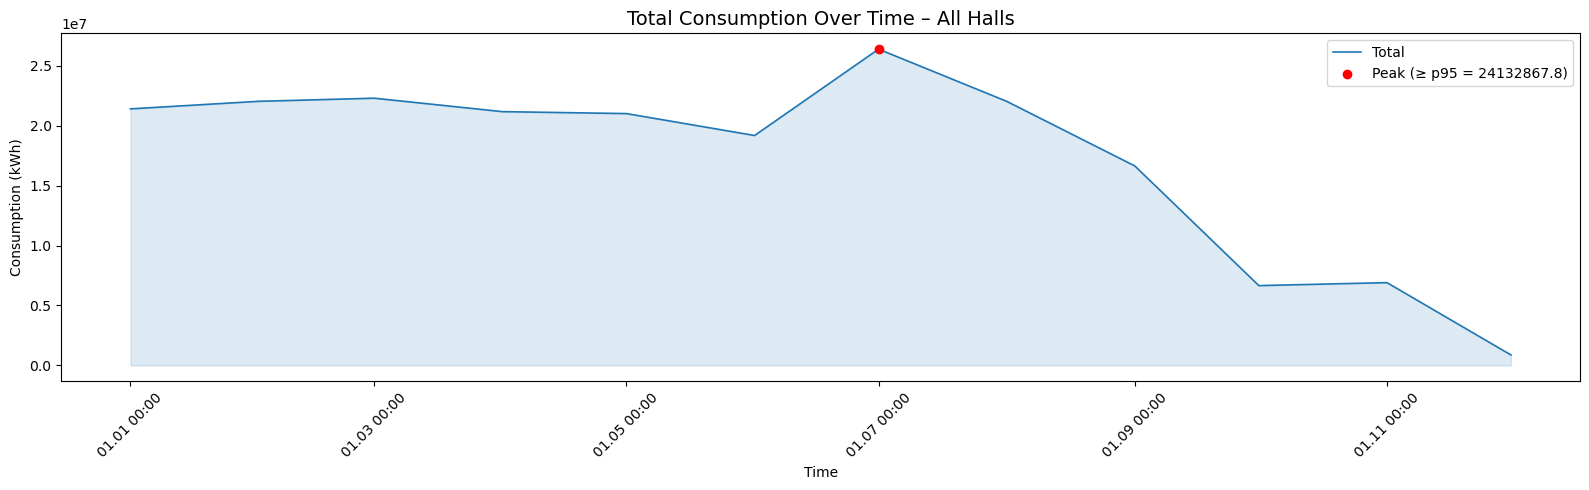

In [38]:
def visualize_total_hall_consumption(df):
    df["time_bucket"] = pd.to_datetime(df["time_bucket"])

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df["time_bucket"], df["total_consumption"], linewidth=1.2, color="#1f77b4", label="Total")
    ax.fill_between(df["time_bucket"], df["total_consumption"], alpha=0.15, color="#1f77b4")

    # Mark peaks (top 5%)
    threshold = df["total_consumption"].quantile(0.95)
    peaks = df[df["total_consumption"] >= threshold]
    ax.scatter(peaks["time_bucket"], peaks["total_consumption"], color="red", zorder=5, label=f"Peak (≥ p95 = {threshold:.1f})")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
    plt.xticks(rotation=45)
    ax.set_title("Total Consumption Over Time – All Halls", fontsize=14)
    ax.set_xlabel("Time")
    ax.set_ylabel("Consumption (kWh)")
    ax.legend()
    plt.tight_layout()
    plt.show()

visualize_total_hall_consumption(total_hall_consumptions)

### 2. Consumption Per Hall Over Time (Drill-Down: Which Hall Peaks?)

In [25]:
consumption_per_hall = con.execute(
"""
SELECT
    hall_id,
    DATE_TRUNC('month', timestamp AT TIME ZONE 'UTC') AS month_bucket,
    SUM(wert) AS total_consumption
FROM fact_measurement
GROUP BY hall_id, month_bucket
ORDER BY month_bucket, hall_id;
""").fetchdf()

consumption_per_hall

,hall_id,month_bucket,total_consumption
0,H1,2025-01-01,4.523269e+05
1,H2,2025-01-01,6.197356e+06
2,H3,2025-01-01,4.560789e+04
3,H4,2025-01-01,2.075156e+06
4,H5,2025-01-01,5.268608e+06
...,...,...,...
91,H4,2025-12-01,0.000000e+00
92,H5,2025-12-01,0.000000e+00
93,H6,2025-12-01,0.000000e+00
94,H7,2025-12-01,3.315814e+05


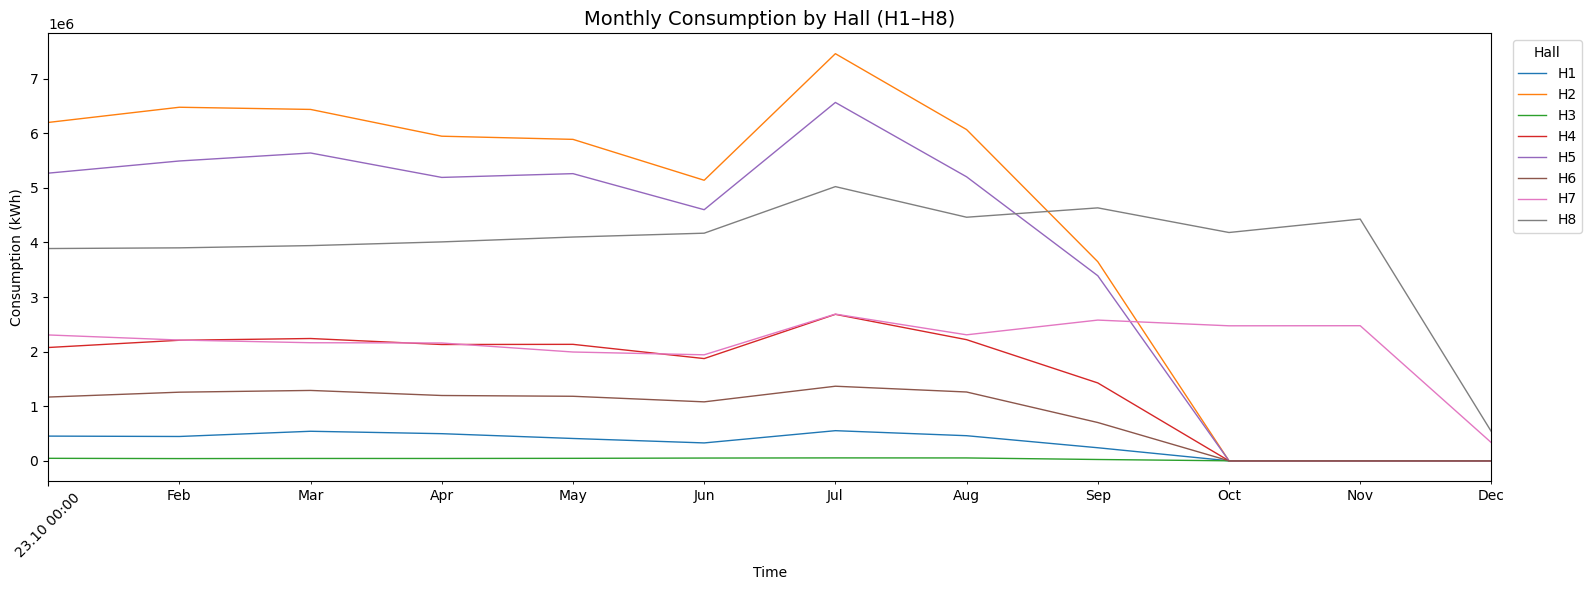

In [39]:
def visualize_consumption_per_hall(df):
    pivot = df.pivot(index="month_bucket", columns="hall_id", values="total_consumption")

    fig, ax = plt.subplots(figsize=(16, 6))
    pivot.plot(ax=ax, linewidth=1.0)
    ax.set_title("Monthly Consumption by Hall (H1–H8)", fontsize=14)
    ax.set_xlabel("Time")
    ax.set_ylabel("Consumption (kWh)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
    plt.xticks(rotation=45)
    plt.legend(title="Hall", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

visualize_consumption_per_hall(consumption_per_hall)

### 3. Consumption by Hall × Hour of Day

In [ ]:
hall_hour = con.execute(
"""
SELECT
    hall_id,
    EXTRACT(HOUR FROM timestamp) AS hour_of_day,
    AVG(wert) AS avg_consumption
FROM fact_measurement
GROUP BY hall_id, EXTRACT(HOUR FROM timestamp)
ORDER BY hall_id, hour_of_day;
""").fetchdf()

hall_hour 

,hall_id,hour_of_day,avg_consumption
0,H1,0,2.844664
1,H1,1,2.809764
2,H1,2,2.712231
3,H1,3,2.654491
4,H1,4,2.611979
...,...,...,...
187,H8,19,10.262078
188,H8,20,10.360860
189,H8,21,10.483898
190,H8,22,10.438628


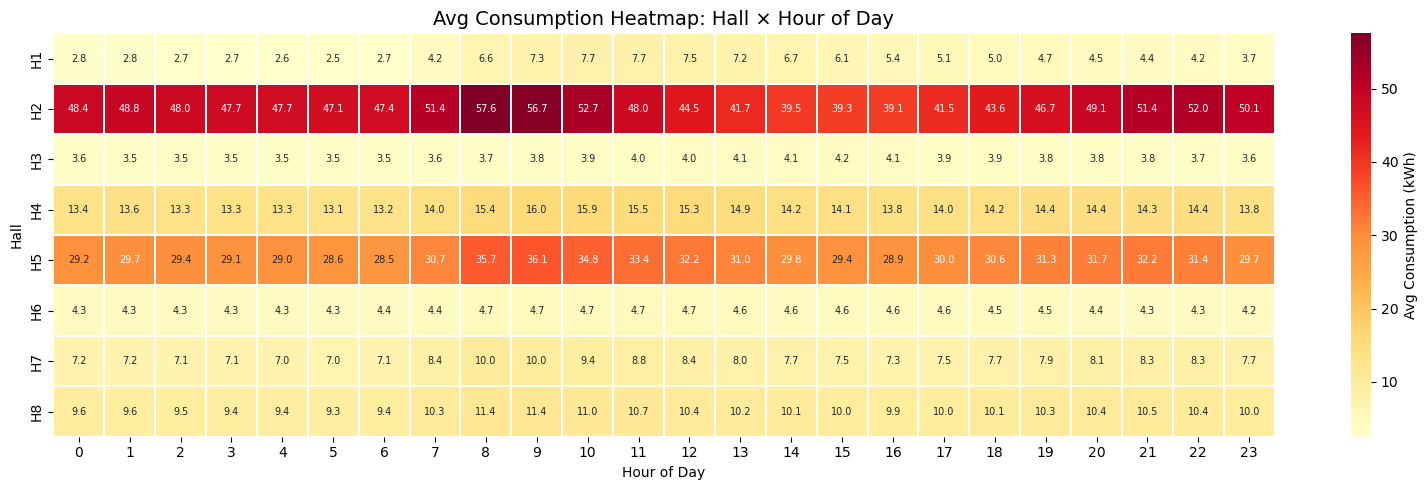

In [40]:

def visualize_hall_hour(df):
    pivot = df.pivot(index="hall_id", columns="hour_of_day", values="avg_consumption")

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(
        pivot, ax=ax, cmap="YlOrRd", linewidths=0.3,
        cbar_kws={"label": "Avg Consumption (kWh)"},
        annot=True, fmt=".1f", annot_kws={"size": 7}
    )
    ax.set_title("Avg Consumption Heatmap: Hall × Hour of Day", fontsize=14)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Hall")
    plt.tight_layout()
    plt.show()
    
visualize_hall_hour(hall_hour)

In [63]:
station_consumption = con.execute(
"""
SELECT
    station_id,
    DATE_TRUNC('hour', timestamp) AS hour_bucket,
    SUM(wert) AS total_consumption,
    MAX(max) AS peak_max
FROM fact_measurement
WHERE hall_id = 'H2' -- Example H2
    AND timestamp BETWEEN '2025-01-15 08:00' AND '2025-01-15 16:00'
GROUP BY station_id, DATE_TRUNC('hour', timestamp)
ORDER BY hour_bucket, station_id;
""").fetchdf()

station_consumption

,station_id,hour_bucket,total_consumption,peak_max
0,station_01,2025-01-15 08:00:00+01:00,915.230453,258.575562
1,station_02,2025-01-15 08:00:00+01:00,359.926711,101.872953
2,station_03,2025-01-15 08:00:00+01:00,5.071628,2.361929
3,station_04,2025-01-15 08:00:00+01:00,2.399668,0.744625
4,station_05,2025-01-15 08:00:00+01:00,0.616727,24.386719
...,...,...,...,...
251,station_28,2025-01-15 15:00:00+01:00,0.000000,0.000000
252,station_29,2025-01-15 15:00:00+01:00,54.335223,18.599500
253,station_30,2025-01-15 15:00:00+01:00,11.458292,2.895854
254,station_31,2025-01-15 15:00:00+01:00,9237.503000,2480.304500


### 4. Station-Level Consumption for a Specific Hall

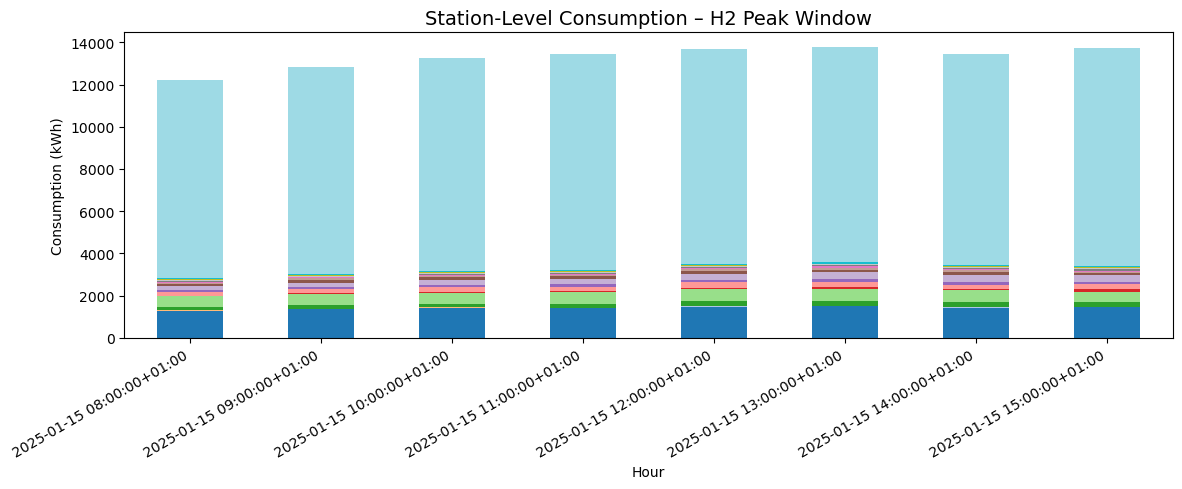

In [64]:
def visualize_consumption_per_station(df):
    df["hour_bucket"] = pd.to_datetime(df["hour_bucket"]).dt.floor("h").astype(str)  # convert to plain string

    pivot = df.pivot(index="hour_bucket", columns="station_id", values="total_consumption")

    fig, ax = plt.subplots(figsize=(12, 5))
    pivot.plot(kind="bar", ax=ax, stacked=True, colormap="tab20")

    ax.set_title("Station-Level Consumption – H2 Peak Window", fontsize=14)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Consumption (kWh)")
    ax.set_xticklabels(pivot.index, rotation=30, ha="right")
    ax.legend().set_visible(False)

    # plt.legend(title="Station", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

visualize_consumption_per_station(station_consumption)

In [72]:
daily_peak = con.execute(
"""
SELECT
    hall_id,
    DATE(timestamp) AS day,
    SUM(wert) AS daily_total,
    MAX(max) AS daily_peak,
    RANK() OVER (PARTITION BY DATE(timestamp) ORDER BY SUM(wert) DESC) AS rank_on_day
FROM fact_measurement
WHERE wert IS NOT NULL AND wert > 0
GROUP BY hall_id, DATE(timestamp)
ORDER BY day, rank_on_day;
""").fetchdf()

daily_peak

,hall_id,day,daily_total,daily_peak,rank_on_day
0,H8,2025-01-01,33433.845407,82.376875,1
1,H7,2025-01-01,25073.058861,82.376875,2
2,H2,2025-01-01,18811.652034,287.575344,3
3,H5,2025-01-01,10396.427009,46.285266,4
4,H6,2025-01-01,7562.993060,16.271833,5
...,...,...,...,...,...
2230,H7,2025-12-02,106169.225696,213.431312,2
2231,H8,2025-12-03,173975.529550,411.523656,1
2232,H7,2025-12-03,110901.577482,242.642188,2
2233,H8,2025-12-04,34525.384110,401.816375,1


In [75]:
def visualize_daily_peak(df):
    df["day"] = pd.to_datetime(df["day"])
    pivot = df.pivot(index="day", columns="hall_id", values="daily_total")
    peak = df.groupby("day")["daily_peak"].max()  # total peak across all halls per day

    fig, ax = plt.subplots(figsize=(16, 6))

    # Stacked area — consumption per hall
    pivot.plot(kind="area", ax=ax, stacked=True, alpha=0.6, colormap="Set2")

    # Peak line on top
    ax.plot(peak.index, peak.values, color="red", linewidth=2, linestyle="--", 
            label="Daily Peak", zorder=5)

    # Mark peak points
    ax.scatter(peak.index, peak.values, color="red", zorder=6, s=40)

    ax.set_title("Daily Total Consumption by Hall + Peak", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel("Consumption (kWh)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
    plt.xticks(rotation=45)
    ax.get_legend().remove()
    plt.tight_layout()
    plt.show()

# visualize_daily_peak(daily_peak)